# 03 - Thermal Model Validation

Loads the 9 mandatory thermal-validation experiment results (`results/thermal_validation/`). See `docs/thermal_model.md` for the equations and parameter provenance -- all thermal parameters are SIMULATION ASSUMPTIONS, never claimed to be physically validated.

In [1]:
import sys, json
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import Image, display, Markdown

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / "src"))
RESULTS = REPO_ROOT / "results"
DOCS = REPO_ROOT / "docs"
DATA = REPO_ROOT / "data" / "processed"


## Pass/fail summary

In [2]:
pd.read_csv(RESULTS / 'tables' / '03_thermal_validation.csv')

,test,status
0,1. Zero cooling + zero workload -> relax towar...,PASS
1,"2. Constant workload, no cooling -> rises mono...",PASS
2,3. Step workload increase -> temperature incre...,PASS
3,4. Step workload decrease -> temperature decre...,PASS
4,5. Cooling step increase -> temperature decreases,PASS
5,6. Cooling step decrease -> temperature increases,PASS
6,7. Zone coupling: heating zone 0 warms 1 and 2...,PASS
7,8. Ambient disturbance: hotter ambient -> high...,PASS
8,"9. Numerical stability: no divergence, no absu...",PASS


## Individual experiment plots

test1_zero_zero.png


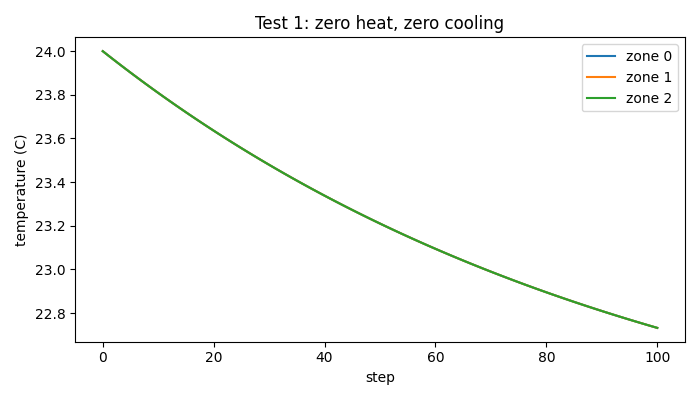

test2_constant_heat.png


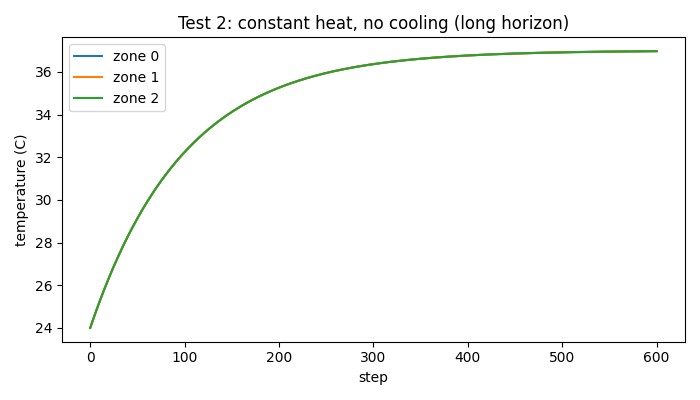

test3_step_up.png


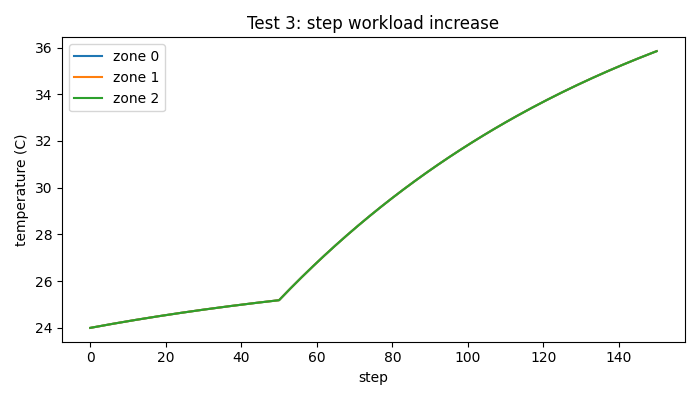

test4_step_down.png


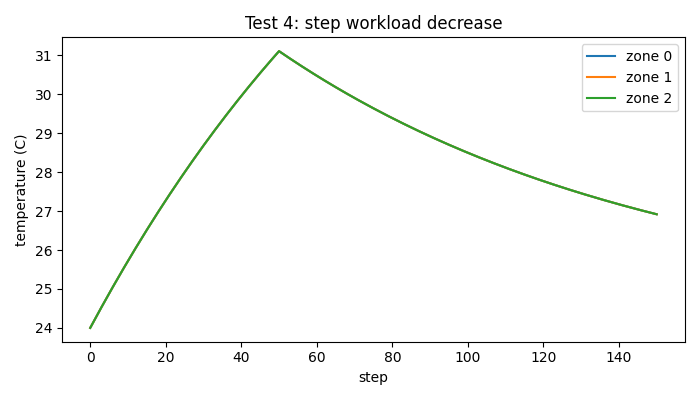

test5_cooling_up.png


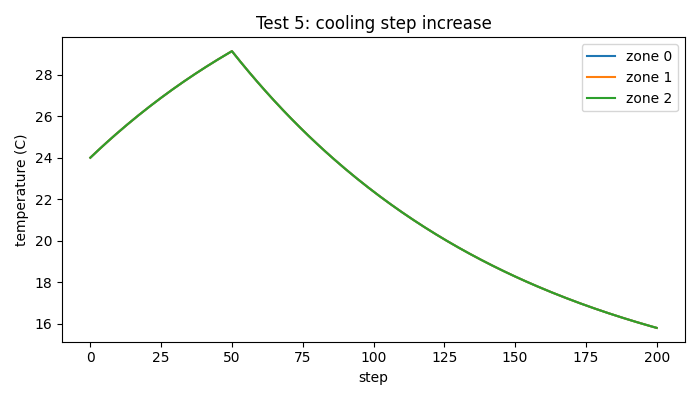

test6_cooling_down.png


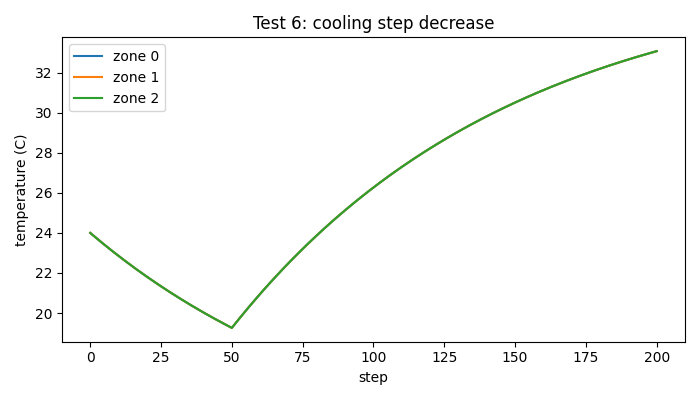

test7_coupling.png


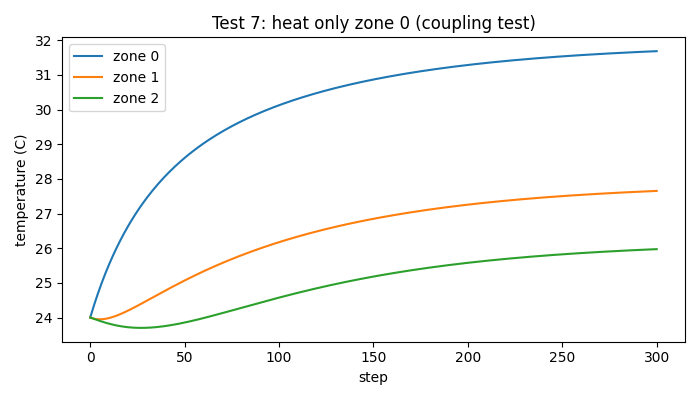

test8_hot_ambient.png


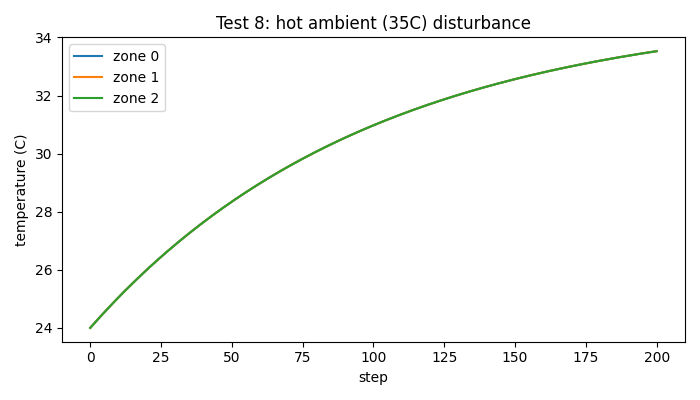

In [3]:
import glob
for p in sorted(glob.glob(str(RESULTS / 'thermal_validation' / 'test*.png'))):
    print(p.split('/')[-1])
    display(Image(filename=p))

## Note on one corrected test (see `docs/experiment_log.md`)

Test 2 (constant workload, no cooling) originally failed with a too-short, too-tightly-toleranced window; the model's dynamics were correct throughout, only the test's horizon was miscalibrated relative to the system's actual thermal time constant. Fixed by deriving the test window from `tau = C/K_amb` and checking convergence to the analytical equilibrium.